In [69]:
# !pip3 install llama-index PyMuPDF

In [70]:
# !pip3 install numpy==1.26.4 

In [71]:
# !pip3 install matplotlib

In [72]:
import fitz
from PIL import Image
import io
from langchain.text_splitter import RecursiveCharacterTextSplitter
from transformers import CLIPModel, CLIPProcessor
import numpy as np
import faiss
import matplotlib.pyplot as plt

In [73]:
file = 'stm_cmos.pdf'
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [ ]:
def extract(file):
    '''Extracts text and images from the document. Extracted images are in the form of bytes'''
    doc = fitz.open(file)
    text = []
    images = []
    for page in doc:
        text.append(page.get_text())
        for i, img in enumerate(page.get_images(full=True)):
            xref = img[0]
            base_img = doc.extract_image(xref)
            img_bytes = base_img["image"]
            images.append(img_bytes)
    return text, images

def show(images):
    '''Displays/Plots Images'''
    fig, ax = plt.subplots(2,1,figsize=(10,10))
    for i, img_bytes in enumerate(images):       
        img = Image.open(io.BytesIO(img_bytes[0]))
        ax[i-1].axis('off')
        ax[i-1].imshow(img)
    plt.show()

def get_text_embedding(text):
    '''Returns the CLIP embedding of the input text'''
    inputs = clip_processor(text=text, padding=True, truncation=True, return_tensors="pt")
    outputs = clip_model.get_text_features(**inputs)
    return outputs.detach().numpy()

def get_image_embedding(img_bytes):
    '''Returns the CLIP embedding of the input imges(bytes)'''
    image = Image.open(io.BytesIO(img_bytes))
    inputs = clip_processor(images=image, return_tensors="pt")
    outputs = clip_model.get_image_features(**inputs)
    return outputs.detach().numpy()

def get_retrieved_texts(text_results, doc_chunks):
    '''based on the predicted values, retrieve the doc chunks'''
    retrieved_texts = []
    for i in text_results.flatten(): 
        if 0 <= i < len(doc_chunks): 
            retrieved_texts.append(doc_chunks[i])
        else:
            print(f"Warning: Index {i} out of bounds for text map.")

    print("\nRetrieved Text Chunks:")
    for text in retrieved_texts:
        print(f"- {text}")

def get_retrieved_images(image_results, images):
    '''based on the predicted values, retrieve the images'''
    retrieved_images = []
    for i in image_results.flatten(): 
        if 0 <= i < len(images): 
            retrieved_images.append([images[i]])
        else:
            print(f"Warning: Index {i} out of bounds for text map.")

    print("\nRetrieved Images:")
    show(retrieved_images)

def retrieve(query_text):
    '''retrieve similar text and query from the vectorstore (faiss)'''
    query_embedding = get_text_embedding(query_text)
    _, text_results = text_index.search(query_embedding, k=2)
    get_retrieved_texts(text_results, doc_chunks)
    _, image_results = image_index.search(query_embedding, k=2)
    get_retrieved_images(image_results, images)


In [ ]:
## extract text and images from original file
text, images = extract(file)

In [ ]:
## split text for embedding and storing
text_splitter = RecursiveCharacterTextSplitter(chunk_size=128, chunk_overlap=16)
doc_chunks = text_splitter.split_text(text[0])

In [ ]:
## embed the text and images
text_embeddings = np.vstack([get_text_embedding(text) for text in doc_chunks])
image_embeddings = np.vstack([get_image_embedding(img_bytes) for img_bytes in images])

In [ ]:
## store text and image embeddings in vectorstore
text_dim = text_embeddings.shape[1]
image_dim = image_embeddings.shape[1]

text_index = faiss.IndexFlatL2(text_dim)  # L2 distance for text
image_index = faiss.IndexFlatL2(image_dim)  # L2 distance for images


In [ ]:
text_index.add(text_embeddings)
image_index.add(image_embeddings)

TEST


Retrieved Text Chunks:
- –
I²C and I3C control interface
–
Effortless integration with VD55G1 development kit, camera modules,
- Features
•
Tiny sensor, which can fit everywhere:
–
World’s first 2.16 µm global shutter pixel for optimum compactness
–

Retrieved Images:


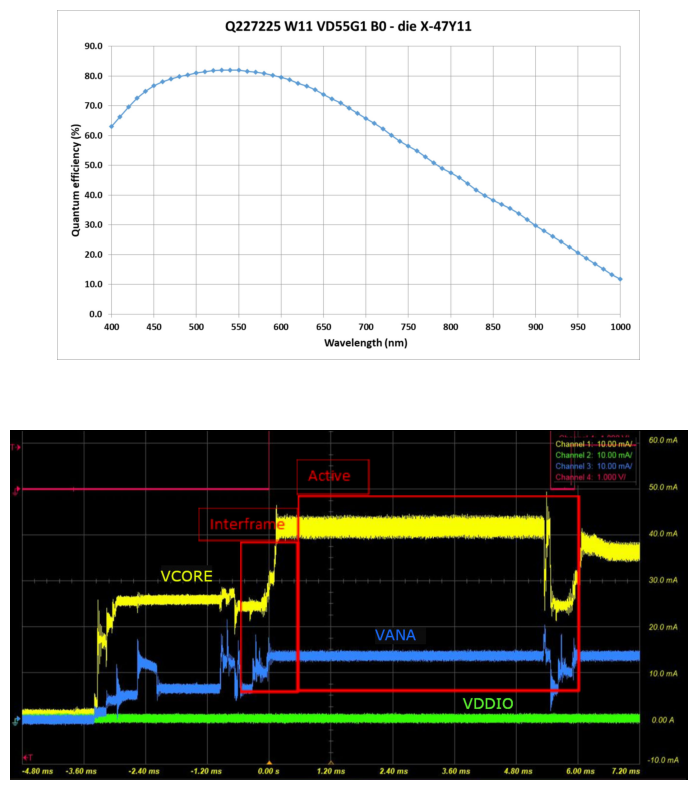

In [83]:
query_text = "What is VD55G1 image signal processor"
query_embedding = get_text_embedding([query_text])
retrieve(query_text)